In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil


drive_dir = '/content/drive/MyDrive/EuroSAT_Split_Physical'


local_dir = '/content/EuroSAT_Split_Physical'

if not os.path.exists(local_dir):
    print("🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...")
    shutil.copytree(drive_dir, local_dir)
    print("✅ Copy done.")
else:
    print("✅ Local copy already exists:", local_dir)


output_dir = local_dir
print("📂 Using dataset root:", output_dir)
print("Subdirs:", os.listdir(output_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...
✅ Copy done.
📂 Using dataset root: /content/EuroSAT_Split_Physical
Subdirs: ['valid', 'train', 'test']


In [ ]:

import os
splits = ['train', 'test', 'valid']
for split in splits:
    split_path = os.path.join(output_dir, split)
    print(f"\nDataset partitioning:{split}")
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        num_images = len(os.listdir(class_path))
        print(f" - class {class_name}: {num_images} images")



Dataset partitioning:train
 - class Highway: 1750 images
 - class AnnualCrop: 2100 images
 - class River: 1750 images
 - class Forest: 2100 images
 - class SeaLake: 2100 images
 - class Residential: 2100 images
 - class HerbaceousVegetation: 2099 images
 - class PermanentCrop: 1750 images
 - class Industrial: 1750 images
 - class Pasture: 1400 images

Dataset partitioning:test
 - class Highway: 375 images
 - class AnnualCrop: 450 images
 - class River: 375 images
 - class Forest: 450 images
 - class SeaLake: 450 images
 - class Residential: 450 images
 - class HerbaceousVegetation: 450 images
 - class PermanentCrop: 375 images
 - class Industrial: 375 images
 - class Pasture: 300 images

Dataset partitioning:valid
 - class Highway: 375 images
 - class AnnualCrop: 450 images
 - class River: 375 images
 - class Forest: 450 images
 - class SeaLake: 450 images
 - class Residential: 450 images
 - class HerbaceousVegetation: 451 images
 - class PermanentCrop: 375 images
 - class Industrial:

📊 Total number of images in dataset: 18899


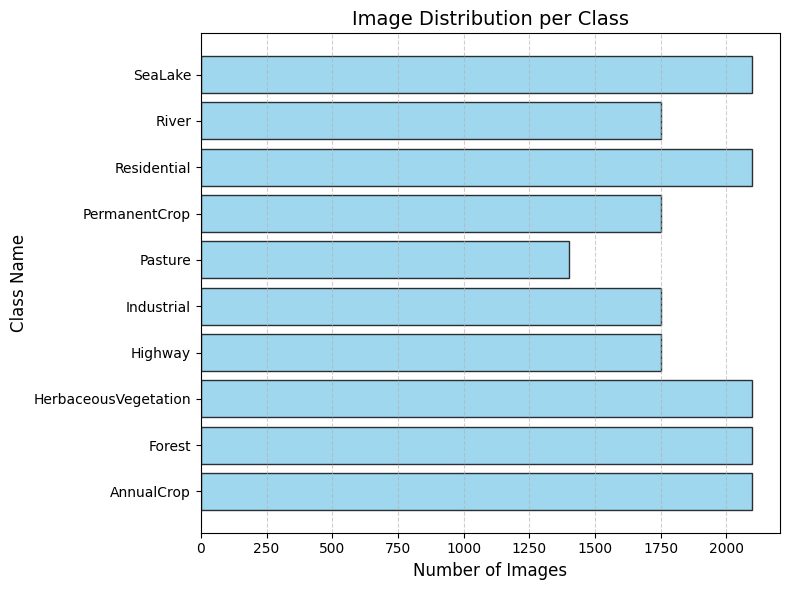

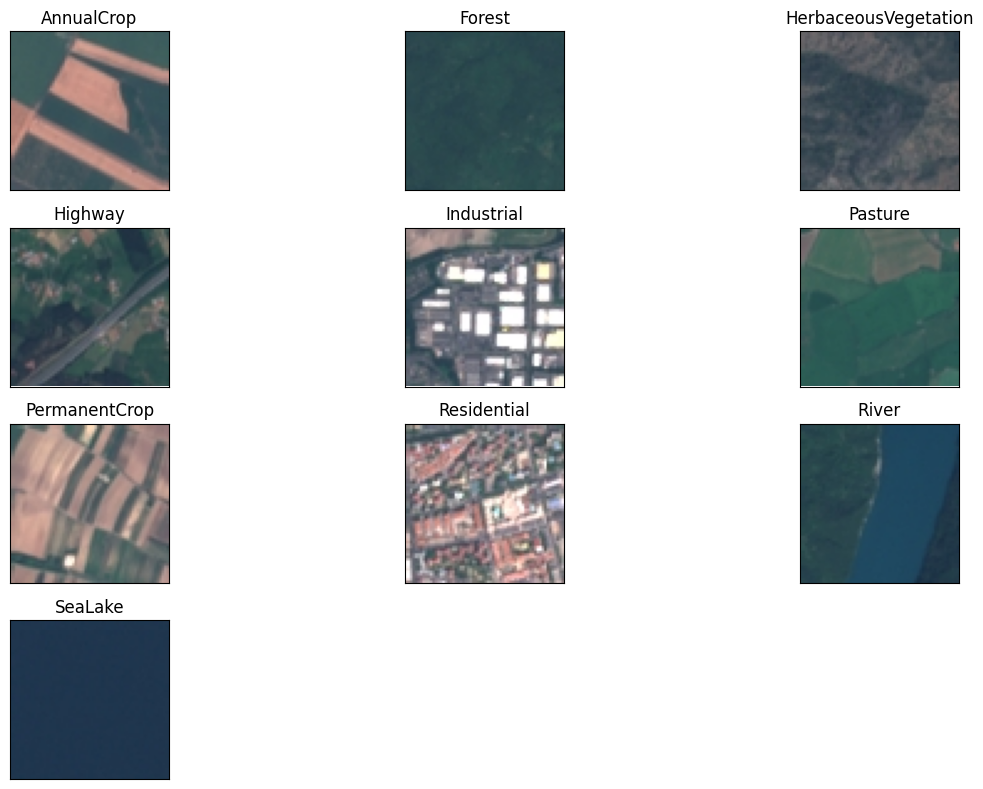

✅ Sample preview done.


In [ ]:

import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def statistic(train_dir=os.path.join(output_dir, 'train')):
    labels, counts = [], []
    for cname in sorted(os.listdir(train_dir)):
        cpath = os.path.join(train_dir, cname)
        if os.path.isdir(cpath):
            labels.append(cname)
            counts.append(len(os.listdir(cpath)))
    return labels, counts

labels, num_images = statistic()
print(f"📊 Total number of images in dataset: {sum(num_images)}")


y_pos = np.arange(len(labels))
plt.figure(figsize=(8, 6))
plt.barh(y_pos, num_images, color='skyblue', edgecolor='black', alpha=0.8)
plt.yticks(y_pos, labels, fontsize=10)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class Name', fontsize=12)
plt.title('Image Distribution per Class', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


train_dir = os.path.join(output_dir, 'train')
samples, names = [], []
for cname in sorted(os.listdir(train_dir)):
    cpath = os.path.join(train_dir, cname)
    if os.path.isdir(cpath):
        files = os.listdir(cpath)
        if files:
            samples.append(Image.open(os.path.join(cpath, files[0])).convert('RGB'))
            names.append(cname)

n = min(len(samples), 12)
plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(4, 3, i+1)
    plt.imshow(samples[i])
    plt.title(names[i])
    plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.show()
print("✅ Sample preview done.")


In [ ]:

def create_label_mapping(train_dir=os.path.join(output_dir, 'train')):
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    return {cls: idx for idx, cls in enumerate(classes)}

label2id = create_label_mapping()
print("✅ label2id:", label2id)


✅ label2id: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"🚀 Using device: {device}")


def create_label_mapping(train_dir=os.path.join(output_dir, 'train')):
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    return {cls: idx for idx, cls in enumerate(classes)}


🚀 Using device: cuda


In [ ]:

def collect_paths_labels(base_dir, label2id):

    img_paths, labels = [], []
    for label, idx in label2id.items():
        class_dir = os.path.join(base_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            p = os.path.join(class_dir, fname)
            if os.path.isfile(p) and p.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                img_paths.append(p)
                labels.append(idx)
    return img_paths, labels

class ImageFolderPaths(Dataset):

    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        path = self.img_paths[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        label = self.labels[idx]
        return img, label


img_size = 224
transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


label2id = create_label_mapping()
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
num_classes = len(class_names)
print(f"✅ Classes ({num_classes}): {class_names}")


train_paths, train_labels = collect_paths_labels(os.path.join(output_dir, 'train'), label2id)
valid_paths, valid_labels = collect_paths_labels(os.path.join(output_dir, 'valid'), label2id)
test_paths,  test_labels  = collect_paths_labels(os.path.join(output_dir, 'test'),  label2id)

# DataLoader
batch_size = 64
train_loader = DataLoader(ImageFolderPaths(train_paths, train_labels, transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
valid_loader = DataLoader(ImageFolderPaths(valid_paths, valid_labels, transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ImageFolderPaths(test_paths,  test_labels,  transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"🔢 Train/Valid/Test sizes: {len(train_paths)} / {len(valid_paths)} / {len(test_paths)}")


✅ Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
🔢 Train/Valid/Test sizes: 18899 / 4051 / 4050


In [ ]:

import torch
import torch.nn as nn
import torchvision.models as models

# Build ResNet18 and replace the classification header with num_classes
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_feats = backbone.fc.in_features
backbone.fc = nn.Linear(in_feats, num_classes)

model = backbone.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

# Learning rate scheduling (simple warmup + cosine)
epochs = 15
warmup_epochs = 1
min_lr = 1e-6
base_lr = 3e-4

def lr_schedule(cur_epoch):
    if cur_epoch < warmup_epochs:
        return (cur_epoch + 1) / warmup_epochs
    t = (cur_epoch - warmup_epochs) / max(1, (epochs - warmup_epochs))
    cosine = 0.5 * (1 + np.cos(np.pi * t))
    return (min_lr / base_lr) + (1 - min_lr / base_lr) * cosine


from torch.utils.data import DataLoader
train_loader_train = DataLoader(
    ImageFolderPaths(train_paths, train_labels, transform),
    batch_size=64, shuffle=True, num_workers=2, pin_memory=True
)


scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

print("✅ Pure ResNet18 classifier ready (end-to-end fine-tuning).")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


✅ Pure ResNet18 classifier ready (end-to-end fine-tuning).


/tmp/ipython-input-39705628.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [ ]:
# ====== Cell 4: Train/Validate loops ======
from tqdm import tqdm
import numpy as np

def accuracy_top1(logits, targets):
    pred = logits.argmax(dim=1)
    return (pred == targets).float().mean().item()

@torch.no_grad()
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    total_n    = 0
    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_top1(logits, labels) * bs
        total_n    += bs

    return total_loss / max(1, total_n), total_acc / max(1, total_n)

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc  = 0.0
    total_n    = 0
    pbar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_top1(logits, labels) * bs
        total_n    += bs

        pbar.set_postfix(loss=f"{total_loss/max(1,total_n):.4f}",
                         acc=f"{total_acc/max(1,total_n):.4f}")

    return total_loss / max(1, total_n), total_acc / max(1, total_n)


In [ ]:

import os

best_val_acc = 0.0
best_ckpt = "./resnet18_pure_best.pt"


epoch_indices = []
epoch_lrs     = []
tr_losses, tr_accs = [], []
val_losses, val_accs = [], []

for epoch in range(epochs):
    # Adjust learning rate
    lr_scale = lr_schedule(epoch)
    for pg in optimizer.param_groups:
        pg["lr"] = base_lr * lr_scale
    cur_lr = optimizer.param_groups[0]['lr']

    # Training and Validation
    print(f"\n[Epoch {epoch+1}/{epochs}] lr={cur_lr:.6f}")
    tr_loss, tr_acc = train_one_epoch(model, train_loader_train, optimizer, device)
    val_loss, val_acc = evaluate(model, valid_loader, device)
    print(f"Train: loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"Valid: loss={val_loss:.4f} acc={val_acc:.4f}")


    epoch_indices.append(epoch + 1)
    epoch_lrs.append(cur_lr)
    tr_losses.append(tr_loss); tr_accs.append(tr_acc)
    val_losses.append(val_loss); val_accs.append(val_acc)


    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(
            {"model": model.state_dict(), "num_classes": num_classes},
            best_ckpt
        )
        print(f"💾 Saved best checkpoint -> {best_ckpt} (val_acc={best_val_acc:.4f})")

print(f"\n✅ Training done. Best Val Acc = {best_val_acc:.4f}")



[Epoch 1/15] lr=0.000300


Training:   0%|          | 0/296 [00:00<?, ?it/s]/tmp/ipython-input-1062060593.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipython-input-1062060593.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Train: loss=0.2117 acc=0.9306 | Valid: loss=0.1009 acc=0.9662
💾 Saved best checkpoint -> ./resnet18_pure_best.pt (val_acc=0.9662)

[Epoch 2/15] lr=0.000300


Train: loss=0.1068 acc=0.9648 | Valid: loss=0.0857 acc=0.9746
💾 Saved best checkpoint -> ./resnet18_pure_best.pt (val_acc=0.9746)

[Epoch 3/15] lr=0.000296


Train: loss=0.0704 acc=0.9756 | Valid: loss=0.1023 acc=0.9664

[Epoch 4/15] lr=0.000285


...

Train: loss=0.0016 acc=0.9998 | Valid: loss=0.0540 acc=0.9854
💾 Saved best checkpoint -> ./resnet18_pure_best.pt (val_acc=0.9854)

[Epoch 12/15] lr=0.000057


Train: loss=0.0017 acc=0.9996 | Valid: loss=0.0546 acc=0.9854

[Epoch 13/15] lr=0.000034


Train: loss=0.0010 acc=0.9998 | Valid: loss=0.0534 acc=0.9877
💾 Saved best checkpoint -> ./resnet18_pure_best.pt (val_acc=0.9877)

[Epoch 14/15] lr=0.000016


Train: loss=0.0010 acc=0.9998 | Valid: loss=0.0534 acc=0.9857

[Epoch 15/15] lr=0.000005


Train: loss=0.0006 acc=1.0000 | Valid: loss=0.0520 acc=0.9864

✅ Training done. Best Val Acc = 0.9877


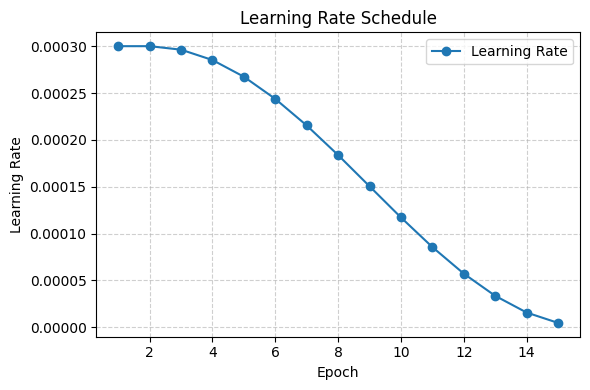

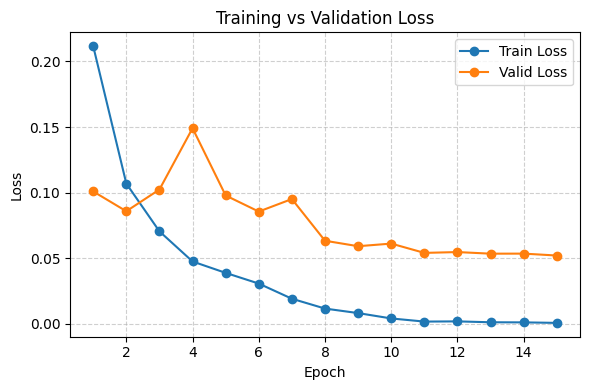

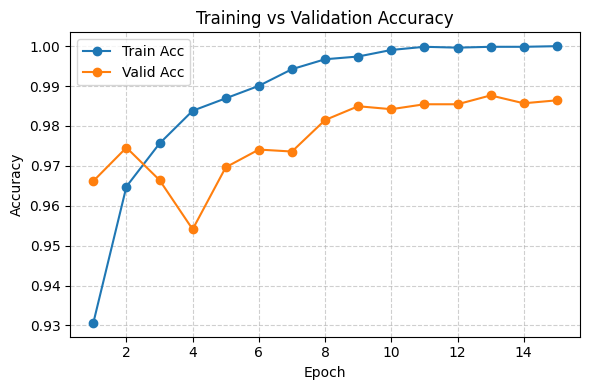

In [ ]:
#  Visualization of LR / Loss / Accuracy curves ======
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))
plt.plot(epoch_indices, epoch_lrs, marker='o', label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
plt.plot(epoch_indices, tr_losses, marker='o', label='Train Loss')
plt.plot(epoch_indices, val_losses, marker='o', label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epoch_indices, tr_accs, marker='o', label='Train Acc')
plt.plot(epoch_indices, val_accs, marker='o', label='Valid Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Testing: 100%|██████████| 64/64 [00:08<00:00,  7.20it/s]


📊 Final Test Accuracy (Pure ResNet18): 0.9852

📋 Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.9753    0.9644    0.9698       450
              Forest     0.9956    0.9978    0.9967       450
HerbaceousVegetation     0.9736    0.9822    0.9779       450
             Highway     0.9868    0.9947    0.9907       375
          Industrial     0.9920    0.9867    0.9893       375
             Pasture     0.9833    0.9833    0.9833       300
       PermanentCrop     0.9650    0.9547    0.9598       375
         Residential     0.9890    0.9978    0.9934       450
               River     0.9946    0.9867    0.9906       375
             SeaLake     0.9956    1.0000    0.9978       450

            accuracy                         0.9852      4050
           macro avg     0.9851    0.9848    0.9849      4050
        weighted avg     0.9852    0.9852    0.9852      4050



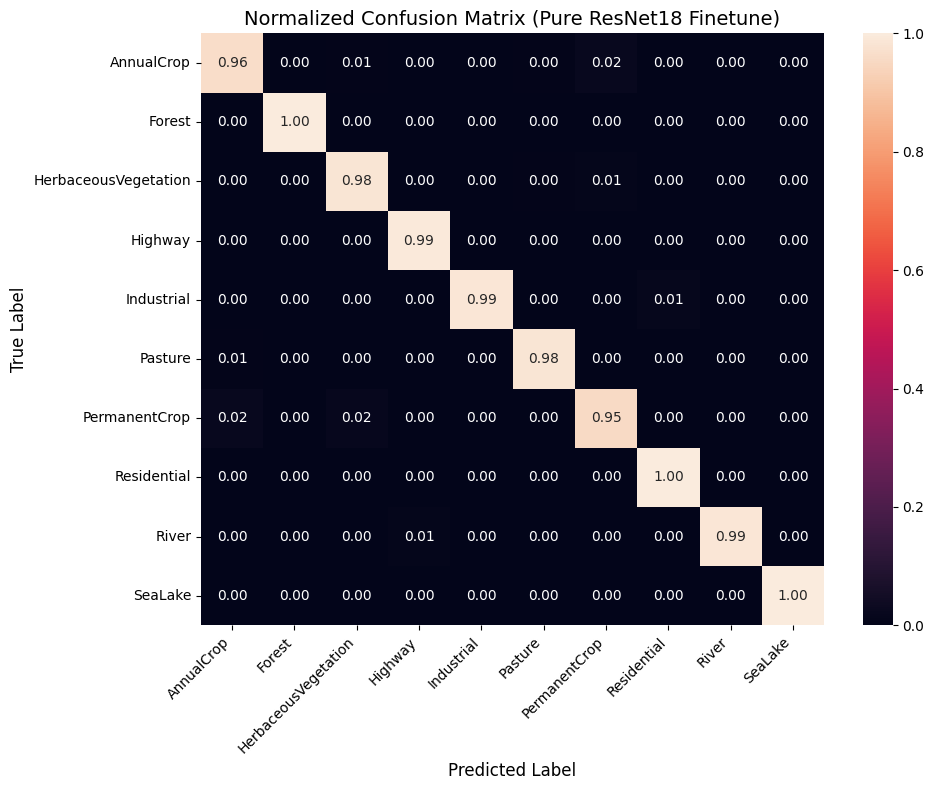

In [ ]:
# Load best & Test evaluation ======
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load optimal weights
ckpt = torch.load("./resnet18_pure_best.pt", map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()


all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        logits = model(images)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(pred)
        all_labels.append(labels.numpy())

Y_pred = np.concatenate(all_preds, axis=0)
Y_test_np = np.concatenate(all_labels, axis=0)

test_acc = accuracy_score(Y_test_np, Y_pred)
print(f"📊 Final Test Accuracy (Pure ResNet18): {test_acc:.4f}\n")

print("📋 Classification Report:")
print(classification_report(Y_test_np, Y_pred, target_names=class_names, digits=4))

# Confusion matrix (row normalized)
cm = confusion_matrix(Y_test_np, Y_pred, labels=list(range(num_classes)))
cm_norm = cm.astype(np.float64) / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Normalized Confusion Matrix (Pure ResNet18 Finetune)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2466656904.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipython-input-2466656904.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


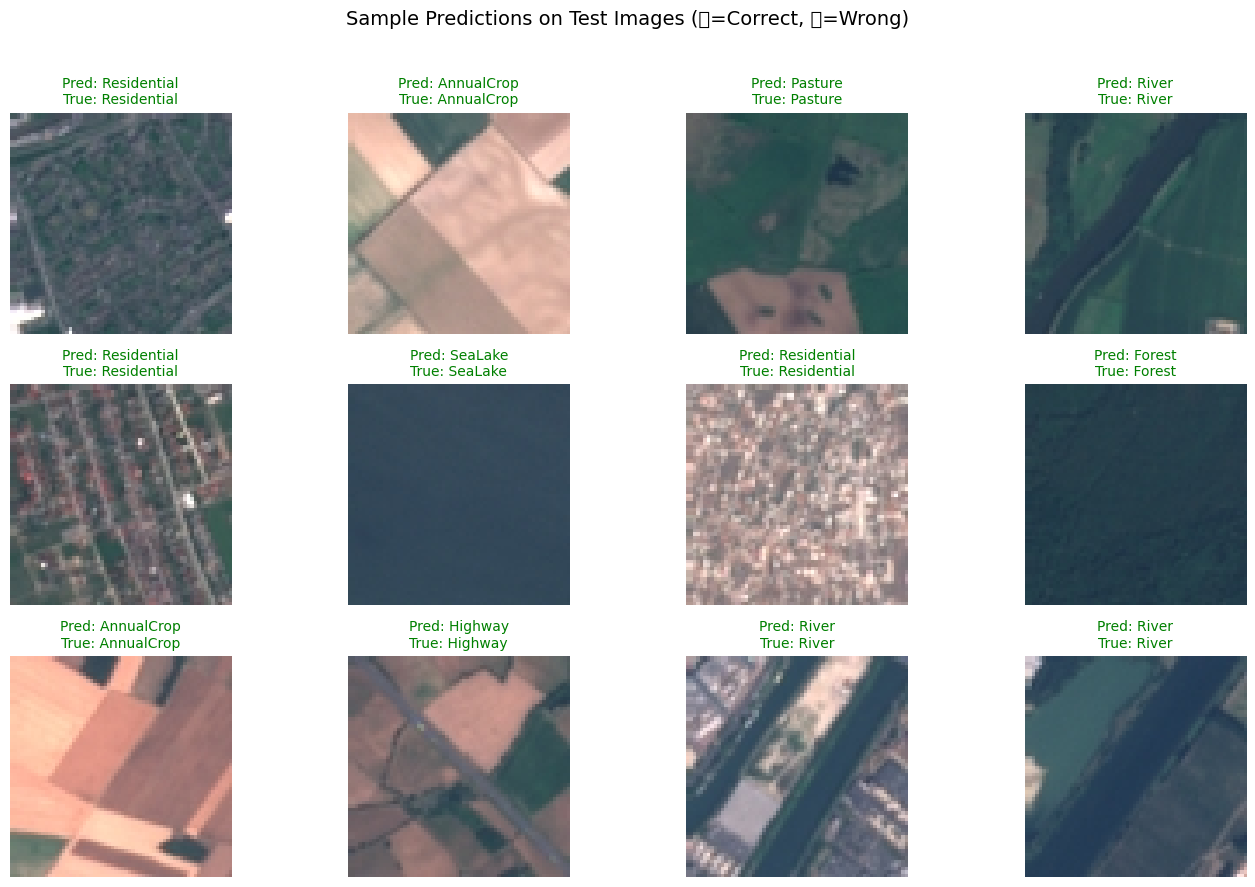

In [ ]:

import random
import matplotlib.pyplot as plt
from PIL import Image


model.eval()


n_show = 12
indices = random.sample(range(len(test_paths)), n_show)

plt.figure(figsize=(14, 9))
for i, idx in enumerate(indices):
    path = test_paths[idx]
    true_label = id2label[test_labels[idx]]


    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        pred_id = logits.argmax(dim=1).item()
    pred_label = id2label[pred_id]


    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.suptitle("Sample Predictions on Test Images (✅=Correct, ❌=Wrong)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Original image size: 2500 x 1131


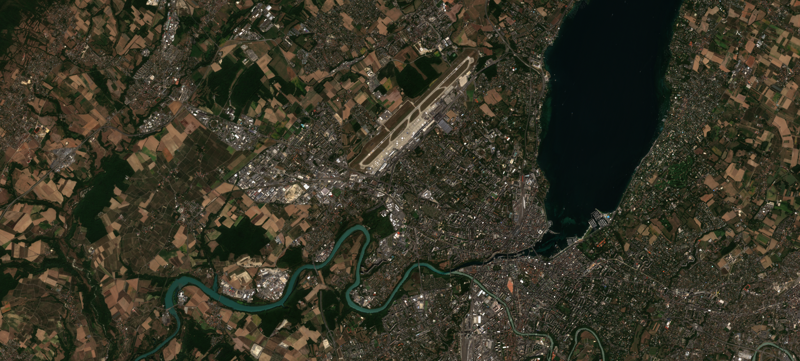

In [ ]:
# Read a complete original Sentinel-2 image
from PIL import Image
import numpy as np


raw_image_path = "/content/drive/MyDrive/2025-08-18-00_00_2025-08-18-23_59_Sentinel-2_L2A_True_Color.png"
big_img = Image.open(raw_image_path).convert("RGB")
W, H = big_img.size
print(f"Original image size: {W} x {H}")


display(big_img.resize((min(W, 800), int(H * min(W, 800) / W))))




In [ ]:
# Cut the entire image into 64x64 smaller pieces

patch_size = 64
stride = patch_size


n_cols = W // patch_size
n_rows = H // patch_size

crop_w = n_cols * patch_size
crop_h = n_rows * patch_size

print(f"Area size for the grid: {crop_w} x {crop_h}")
print(f"patch grid: {n_rows}  x {n_cols} ， {n_rows * n_cols}  patchs")


big_img_cropped = big_img.crop((0, 0, crop_w, crop_h))

patches = []
for r in range(n_rows):
    for c in range(n_cols):
        left   = c * stride
        upper  = r * stride
        right  = left + patch_size
        lower  = upper + patch_size
        patch  = big_img_cropped.crop((left, upper, right, lower))
        patches.append(patch)

print("✅ patch Extraction complete")


Area size for the grid: 2496 x 1088
patch grid: 17  x 39 ， 663  patchs
✅ patch Extraction complete


In [ ]:
#  ResNet18 makes predictions for all patches.
import torch

model.eval()
batch_size_eval = 128

all_preds = []

with torch.no_grad():
    for i in range(0, len(patches), batch_size_eval):
        batch_patches = patches[i : i + batch_size_eval]


        batch_tensors = [transform(p) for p in batch_patches]
        batch = torch.stack(batch_tensors).to(device)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(batch)
            preds = logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)

all_preds = np.array(all_preds)
print("✅ Prediction complete. Number of predictions:", len(all_preds))

# reshape 成 (n_rows, n_cols) 网格
pred_grid = all_preds.reshape(n_rows, n_cols)
pred_grid.shape


/tmp/ipython-input-2784554187.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


✅ Prediction complete. Number of predictions: 663


(17, 39)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


patch_size = 64
pred_full_res = np.kron(pred_grid, np.ones((patch_size, patch_size), dtype=int))
crop_h, crop_w = pred_full_res.shape

print("pred_full_res shape:", pred_full_res.shape)  # (crop_h, crop_w)


big_img_cropped_final = big_img.crop((0, 0, crop_w, crop_h))


color_list = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3"
]
assert len(color_list) >= len(class_names)
cmap = ListedColormap(color_list[:len(class_names)])


plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(big_img_cropped_final)
plt.title(f"Cropped Original ({crop_w}×{crop_h})", fontsize=12)
plt.axis("off")

plt.subplot(1, 2, 2)
im = plt.imshow(pred_full_res, cmap=cmap,
                vmin=0, vmax=len(class_names)-1,
                interpolation="nearest")
plt.title("Prediction (Pure ResNet18, Pixel-level)", fontsize=12)
plt.axis("off")


cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)

plt.tight_layout()


plt.savefig("comparison_resnet.png", dpi=300)
plt.show()

print("📝 Orginal Size：", (W, H))
print("✂️ Cut Size：", (crop_w, crop_h))
print("🎉 Comparison images have been saved.：comparison_resnet.png")

